# SentinelMail — Bi-LSTM + char-CNN: Training & Evaluation

Trains `models/bilstm/BiLSTMCharCNN` via `models.bilstm.train.fit()` (which builds the vocabulary from the FIT slice and saves `vocab.json` + `run_meta.json` next to the checkpoint) and evaluates it once on the untouched `validation` TEST split. Saves metrics to `evaluation/results/bilstm_metrics.json` for ensemble comparison.

**Split roles** (comment 001): FIT = 90% of `train` (parameter training) · DEV = seeded 10% train-holdout (checkpoint selection only) · TEST = `validation` (untouched, final reporting only).

**Prerequisites**
- GloVe 6B 100d at `data/embeddings/glove.6B.100d.txt` (https://nlp.stanford.edu/data/glove.6B.zip); `fit()` hard-fails without it unless `allow_random_init=True`

## 1. Setup

In [25]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

CHECKPOINT_DIR = REPO_ROOT / "models" / "bilstm" / "checkpoint"
GLOVE_PATH     = REPO_ROOT / "data" / "embeddings" / "glove.6B.100d.txt"
RESULTS_DIR    = REPO_ROOT / "evaluation" / "results"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print(f"Device: {DEVICE}")
print(f"GloVe available: {GLOVE_PATH.exists()}")


Device: mps
GloVe available: True


In [26]:
import json
from data.preprocessing import load_split, load_train_holdout, LABEL_COLS
from models.bilstm.predict import BiLSTMDLPDetector
from evaluation import (
    compute_all_metrics,
    classify_errors,
    error_summary,
    plot_confusion_matrices,
    plot_per_label_bars,
    plot_roc_curves,
    plot_pr_curves,
    save_results,
    from_dataframe,
    LABEL_COLS,
)


## 2. Load Data

In [27]:
print("Loading splits...")
# Three split roles (comment 001):
#   FIT  — 90% of `train`: model parameter training (used inside fit()).
#   DEV  — seeded 10% train-holdout: early stopping / checkpoint selection only.
#   TEST — the ai4privacy `validation` split: untouched, final reporting only.
train_df, dev_df = load_train_holdout(frac=0.10, seed=42)
test_df = load_split("validation")

test_texts  = test_df["source_text"].tolist()
test_labels = test_df[LABEL_COLS].values.astype(np.float32)

print(f"Train (FIT):       {len(train_df):,} samples")
print(f"DEV (selection):   {len(dev_df):,} samples")
print(f"TEST (validation): {len(test_df):,} samples")
print()
print("Label distribution (FIT):")
print(train_df[LABEL_COLS].sum().to_string())


Loading splits...
Train (FIT):       26,917 samples
DEV (selection):   2,991 samples
TEST (validation): 7,946 samples

Label distribution (FIT):
benign           3124
PII             23793
financial        5117
confidential    11905


## 3. Train

Delegates to `models.bilstm.train.fit()` — the exact code path used by `python -m models.bilstm.train` and the k-fold CV orchestrator, so notebook and CLI training are identical. `fit()` trains on the 90% FIT slice and selects the checkpoint on the 10% train-holdout DEV (best DEV loss). The `validation` TEST split is **never read during training**.

**Note:** running this cell always retrains and overwrites `checkpoint/best_model.pt` (and takes hours on MPS).

In [28]:
from argparse import Namespace
from models.bilstm.train import fit

CKPT = CHECKPOINT_DIR / "best_model.pt"
args = Namespace(epochs=20, batch_size=64, lr=1e-3,
                 allow_random_init=False, use_char_cnn=True)

ckpt_path, best_dev_loss = fit(train_df, dev_df, args, CKPT, device=DEVICE)


Device: mps
Building vocabulary...
Vocab: 40401 words, 283 chars
GloVe: 11998/40399 vocab words initialised from GloVe vectors.
Config: glove_loaded=True  use_char_cnn=True  freeze_word_emb=True
Epoch 01/20  train=0.4779  val=0.3251
  → checkpoint saved (val_loss=0.3251)
Epoch 02/20  train=0.2619  val=0.2145
  → checkpoint saved (val_loss=0.2145)
Epoch 03/20  train=0.1852  val=0.1814
  → checkpoint saved (val_loss=0.1814)
Epoch 04/20  train=0.1520  val=0.1540
  → checkpoint saved (val_loss=0.1540)
Epoch 05/20  train=0.1267  val=0.1606
Epoch 06/20  train=0.1116  val=0.1537
  → checkpoint saved (val_loss=0.1537)
Epoch 07/20  train=0.0947  val=0.1396
  → checkpoint saved (val_loss=0.1396)
Epoch 08/20  train=0.0805  val=0.1422
Epoch 09/20  train=0.0690  val=0.1496
Epoch 10/20  train=0.0634  val=0.2084
Epoch 11/20  train=0.0520  val=0.1772
Epoch 12/20  train=0.0473  val=0.1635
Epoch 13/20  train=0.0427  val=0.1578
Epoch 14/20  train=0.0404  val=0.1764
Epoch 15/20  train=0.0318  val=0.1807
E

## 4. Load Best Checkpoint

In [29]:
CKPT     = CHECKPOINT_DIR / "best_model.pt"
VOC_PATH = CHECKPOINT_DIR / "vocab.json"

detector = BiLSTMDLPDetector(
    checkpoint_path=str(CKPT),
    vocab_path=str(VOC_PATH),
    device=str(DEVICE),
)
print(f"Loaded: {CKPT.name}")

Loaded: best_model.pt


## 5. Run Inference on the TEST Split (`validation`)

In [30]:
THRESHOLD = 0.5

print(f"Running predict_proba on {len(test_texts):,} samples...")
y_proba = detector.predict_proba(test_texts)       # (N, 4) float32
y_pred  = (y_proba >= THRESHOLD).astype(np.int32) # (N, 4) int
y_true  = from_dataframe(test_df)                   # (N, 4) int

print(f"y_proba range: [{y_proba.min():.3f}, {y_proba.max():.3f}]")
print()
print(f"{'label':14s}  {'pred':>6s}  {'true':>6s}")
for i, col in enumerate(LABEL_COLS):
    print(f"  {col:12s}  {y_pred[:,i].sum():6d}  {y_true[:,i].sum():6d}")

Running predict_proba on 7,946 samples...
y_proba range: [0.000, 1.000]

label             pred    true
  benign          1192     908
  PII             6752    7038
  financial       1663    1529
  confidential    3556    3632


## 6. Metrics

In [31]:
metrics = compute_all_metrics(y_true, y_pred, y_proba=y_proba)

ci = metrics["macro_f1_ci"]
print(f"Macro-F1:      {metrics['macro_f1']:.4f}  "
      f"(95% CI: [{ci['lower']:.4f}, {ci['upper']:.4f}])")
print(f"Macro AUC-ROC: {metrics['auc_roc']['macro']:.4f}")
print()

pd.DataFrame(metrics["per_label"]).T.round(4)

Macro-F1:      0.9398  (95% CI: [0.9353, 0.9438])
Macro AUC-ROC: 0.9875



,precision,recall,f1,support
benign,0.7223,0.9482,0.8200,908.0
PII,0.9932,0.9528,0.9726,7038.0
financial,0.8653,0.9411,0.9016,1529.0
confidential,0.9553,0.9353,0.9452,3632.0


### 6a. Threshold Sensitivity (0.3 / 0.5 / 0.7)

In [32]:
rows = []
for t in [0.3, 0.5, 0.7]:
    m = compute_all_metrics(y_true, (y_proba >= t).astype(np.int32), n_bootstrap=50)
    row = {"threshold": t, "macro_f1": round(m["macro_f1"], 4)}
    for label in LABEL_COLS:
        row[f"{label}_f1"] = round(m["per_label"][label]["f1"], 4)
    rows.append(row)

pd.DataFrame(rows).set_index("threshold")

,macro_f1,benign_f1,PII_f1,financial_f1,confidential_f1
threshold,,,,,
0.3,0.9295,0.7896,0.9761,0.8673,0.9450
0.5,0.9398,0.8200,0.9726,0.9016,0.9452
0.7,0.9419,0.8380,0.9660,0.9198,0.9398


## 7. Confusion Matrices & Per-Label Bars

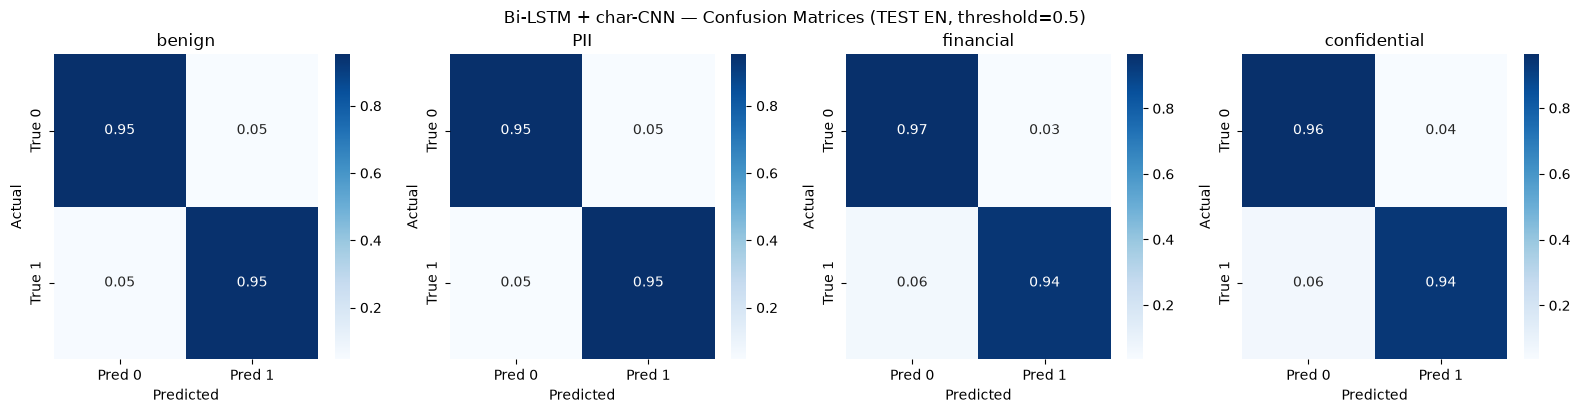

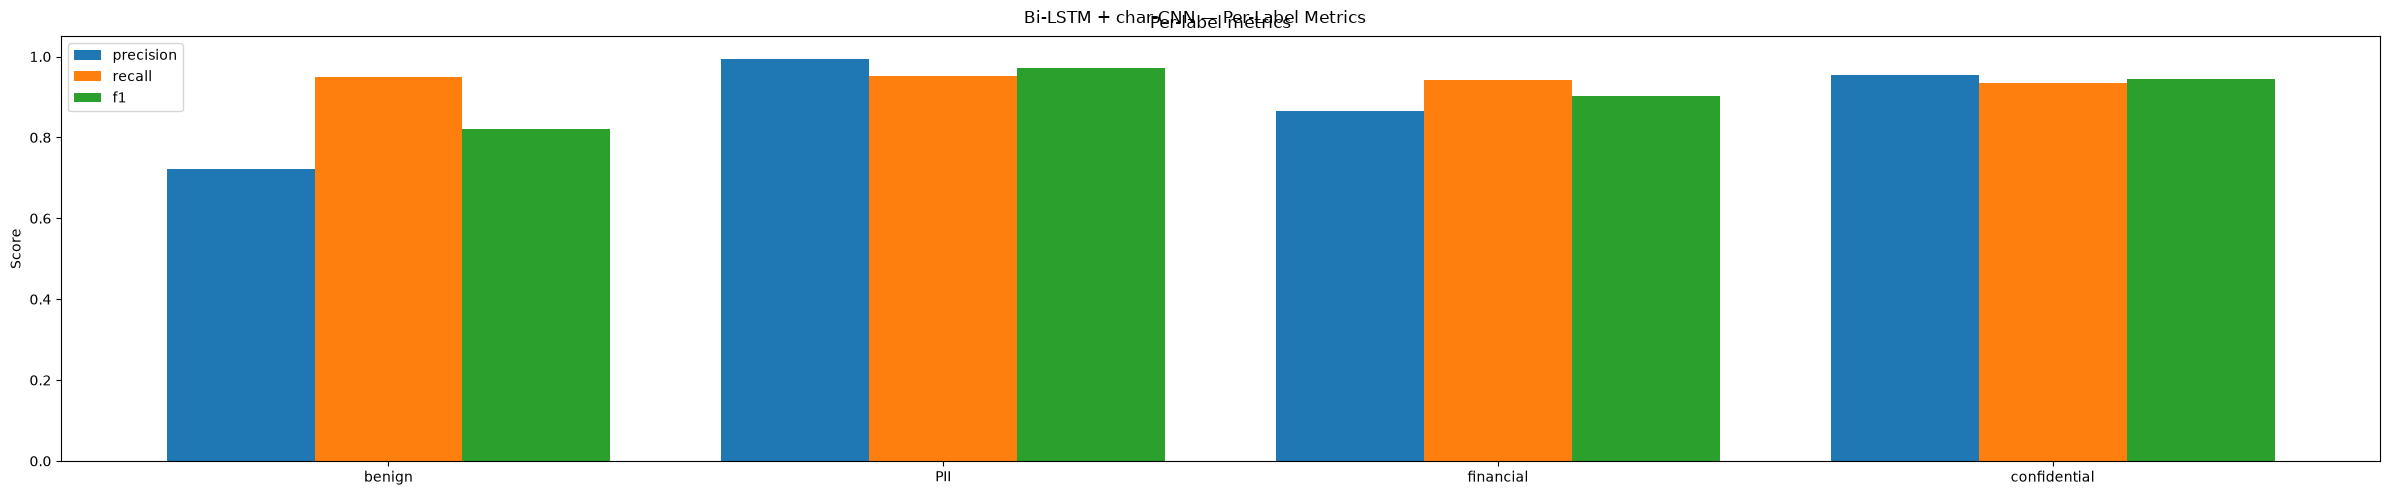

In [33]:
_, fig = plot_confusion_matrices(y_true, y_pred, normalize="true", return_fig=True)
fig.suptitle("Bi-LSTM + char-CNN — Confusion Matrices (TEST EN, threshold=0.5)", y=1.02)
plt.show()

_, bar_fig = plot_per_label_bars(metrics, return_fig=True)
bar_fig.suptitle("Bi-LSTM + char-CNN — Per-Label Metrics")
plt.show()

## 8. ROC & PR Curves

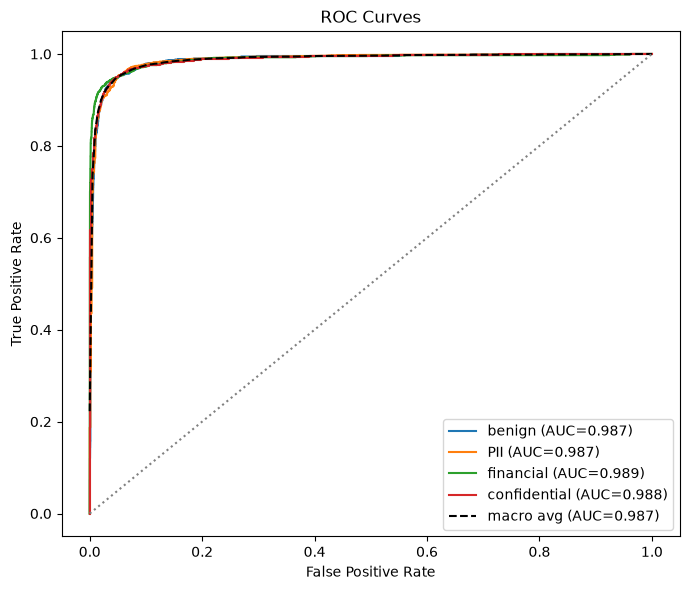

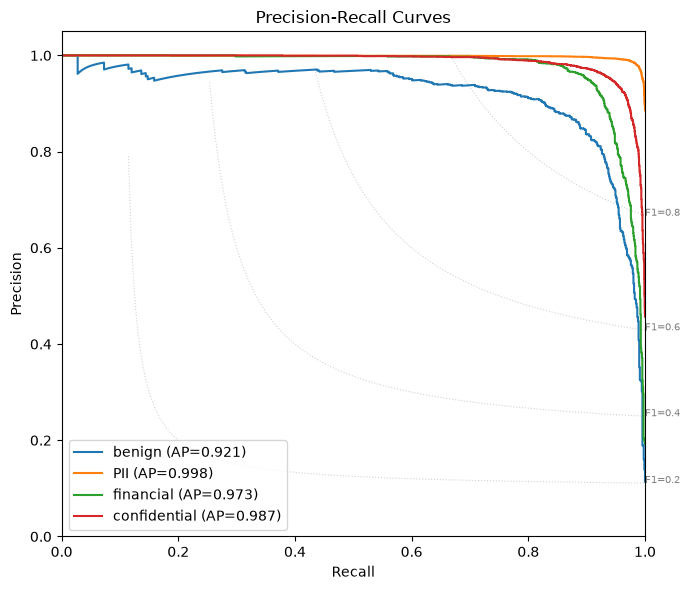

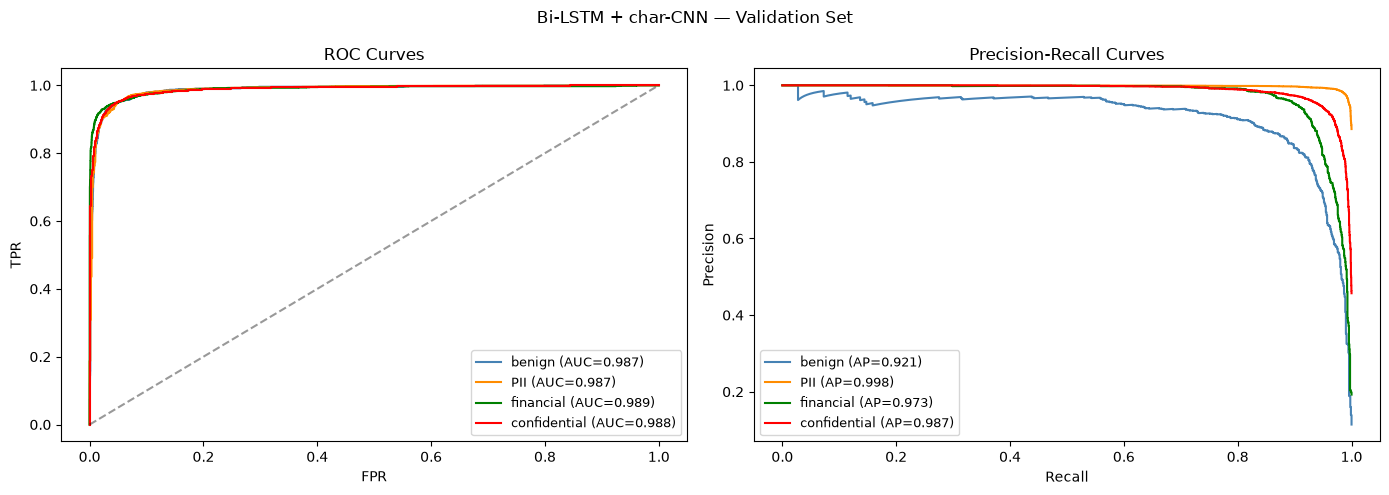

In [34]:
roc_data = plot_roc_curves(y_true, y_proba)
pr_data  = plot_pr_curves(y_true, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
COLORS = ["steelblue", "darkorange", "green", "red"]

for i, label in enumerate(LABEL_COLS):
    axes[0].plot(roc_data[label]["fpr"], roc_data[label]["tpr"],
                 label=f"{label} (AUC={roc_data[label]['auc']:.3f})", color=COLORS[i])
    axes[1].plot(pr_data[label]["recall"], pr_data[label]["precision"],
                 label=f"{label} (AP={pr_data[label]['ap']:.3f})", color=COLORS[i])

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC Curves"); axes[0].legend(fontsize=9)
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves"); axes[1].legend(fontsize=9)
fig.suptitle("Bi-LSTM + char-CNN — Validation Set")
plt.tight_layout()
plt.show()

## 9. Error Analysis

Classifies FP/FN into the four taxonomy buckets (descriptive error analysis for RQ1/RQ2 model comparison).

In [35]:
texts = test_df["source_text"].tolist()

error_results = classify_errors(
    texts, y_true, y_pred,
    max_examples=20,
)

summary_df = error_summary(error_results)
print("Error counts by type and label:")
display(summary_df.pivot(index="error_type", columns="label", values="count").fillna(0).astype(int))

Error counts by type and label:


label,PII,benign,confidential,financial
error_type,,,,
FN_implicit,2,1,20,4
FN_obfuscated,4,0,20,5
FP_hypothetical,1,8,2,3
FP_negation,5,20,11,14
other_FN,20,20,20,20
other_FP,20,20,20,20


In [36]:
def show_bucket(key: str, n: int = 5) -> None:
    records = error_results.get(key, [])
    print(f"\n{'─'*60}")
    print(f"{key}  ({len(records)} total, showing {min(n, len(records))})")
    print(f"{'─'*60}")
    for r in records[:n]:
        print(f"  [{r['label']}] {r['text_snippet'][:120].replace(chr(10), ' ')}")

show_bucket("FP_negation")
show_bucket("FP_hypothetical")
show_bucket("FN_obfuscated")
show_bucket("FN_implicit")


────────────────────────────────────────────────────────────
FP_negation  (50 total, showing 5)
────────────────────────────────────────────────────────────
  [financial] mber: 0091 44 034 6283  5. [Lady]    Contact Number: +3-32-058 5339  6. [Count]    Contact Number: 0098 17351853  We are
  [benign]             <King>                 </SEX_J>                 <Prefer not to disclose>                     <Excellence>   
  [financial] **Cultural Exchange Program Application Form**  **General Information** Applicant Full Name: Roudin   Applicant Username
  [benign] rovided   Applicant's Spouse Given Name: Not Applicable   Applicant's Nationality: Not Disclosed   Applicant's Date of B
  [benign] oring sessions. 3.2 Should the Tutor need to cancel a session for unforeseen circumstances, a makeup session will be sch

────────────────────────────────────────────────────────────
FP_hypothetical  (14 total, showing 5)
────────────────────────────────────────────────────────────
  [confidentia

## 10. Save Results

In [37]:
out_path = RESULTS_DIR / "bilstm_metrics.json"

# fit() persists the *actual* trained configuration next to the checkpoint
# (comment 012) — report from there rather than re-deriving it.
run_meta = json.loads((CHECKPOINT_DIR / "run_meta.json").read_text())

save_results(
    metrics,
    path=out_path,
    model_name="bilstm_charcnn",
    n_samples=len(test_df),
    threshold=THRESHOLD,
    extra_metadata={
        "epochs": run_meta["epochs"],
        "batch_size": run_meta["batch_size"],
        "lr": run_meta["lr"],
        "vocab_size": run_meta["vocab_size"],
        "glove_available": run_meta["glove_loaded"],
        "use_char_cnn": run_meta["use_char_cnn"],
        "freeze_word_emb": run_meta["freeze_word_emb"],
        "checkpoint": str(CKPT),
        "selection_split": "train_holdout(frac=0.10, seed=42)",
        "test_split": "validation",
    },
)

print(f"Saved to {out_path}")


Saved to /Users/erelv/projects-chkp/final-project/evaluation/results/bilstm_metrics.json


## 11. Cross-Validation Robustness (5-fold on train split)

CV was run on the ai4privacy **train** split; the held-out **validation** (test) split
was never touched. Results show mean ± std across 5 folds, confirming that the
single-run test metrics are not a lucky split.

In [38]:
import json

kfold_path = RESULTS_DIR / "kfold_cv_bilstm.json"
with open(kfold_path) as f:
    kfold = json.load(f)

agg = kfold["aggregated"]

rows = []
for label in LABEL_COLS:
    cv_mean = agg["per_label"][label]["f1_mean"]
    cv_std  = agg["per_label"][label]["f1_std"]
    test_f1 = metrics["per_label"][label]["f1"]
    rows.append({
        "label":           label,
        "CV mean F1":      round(cv_mean, 4),
        "CV std":          round(cv_std,  4),
        "Test F1":         round(test_f1, 4),
        "delta (test-CV)": round(test_f1 - cv_mean, 4),
    })

rows.append({
    "label":           "MACRO",
    "CV mean F1":      round(agg["macro_f1_mean"], 4),
    "CV std":          round(agg["macro_f1_std"],  4),
    "Test F1":         round(metrics["macro_f1"],  4),
    "delta (test-CV)": round(metrics["macro_f1"] - agg["macro_f1_mean"], 4),
})

cv_df = pd.DataFrame(rows).set_index("label")
print(f"CV config: {agg['configuration']}  |  k={kfold['k']}  |  seed={kfold['seed']}")
display(cv_df)

CV config: solo_bilstm  |  k=5  |  seed=42


,CV mean F1,CV std,Test F1,delta (test-CV)
label,,,,
benign,0.8402,0.0229,0.8200,-0.0202
PII,0.9757,0.0043,0.9726,-0.0031
financial,0.9049,0.0156,0.9016,-0.0033
confidential,0.9431,0.0064,0.9452,0.0021
MACRO,0.9412,0.0064,0.9398,-0.0014


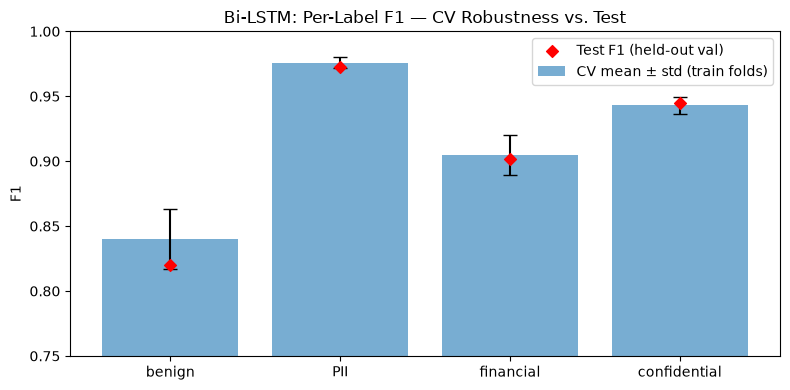

In [39]:
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(LABEL_COLS))
cv_means = [agg["per_label"][l]["f1_mean"] for l in LABEL_COLS]
cv_stds  = [agg["per_label"][l]["f1_std"]  for l in LABEL_COLS]
test_f1s = [metrics["per_label"][l]["f1"] for l in LABEL_COLS]

ax.bar(x, cv_means, yerr=cv_stds, capsize=5, alpha=0.6, label="CV mean ± std (train folds)")
ax.scatter(x, test_f1s, marker="D", color="red", zorder=5, label="Test F1 (held-out val)")
ax.set_xticks(list(x))
ax.set_xticklabels(LABEL_COLS)
ax.set_ylabel("F1")
ax.set_ylim(0.75, 1.0)
ax.set_title("Bi-LSTM: Per-Label F1 — CV Robustness vs. Test")
ax.legend()
plt.tight_layout()
plt.show()